In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro
from scipy.stats import mannwhitneyu

In [2]:
df1 = pd.read_csv("men_results.csv")
df2 = pd.read_csv("women_results.csv")

In [5]:
df1.head()

,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament
0,0,1872-11-30,Scotland,England,0,0,Friendly
1,1,1873-03-08,England,Scotland,4,2,Friendly
2,2,1874-03-07,Scotland,England,2,1,Friendly
3,3,1875-03-06,England,Scotland,2,2,Friendly
4,4,1876-03-04,Scotland,England,3,0,Friendly


In [6]:
df2.head()

,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament
0,0,1969-11-01,Italy,France,1,0,Euro
1,1,1969-11-01,Denmark,England,4,3,Euro
2,2,1969-11-02,England,France,2,0,Euro
3,3,1969-11-02,Italy,Denmark,3,1,Euro
4,4,1975-08-25,Thailand,Australia,3,2,AFC Championship


In [8]:
df1["gender"] = "men"
df2["gender"] = "women"
df = pd.concat([df1, df2], ignore_index = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49237 entries, 0 to 49236
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  49237 non-null  int64 
 1   date        49237 non-null  object
 2   home_team   49237 non-null  object
 3   away_team   49237 non-null  object
 4   home_score  49237 non-null  int64 
 5   away_score  49237 non-null  int64 
 6   tournament  49237 non-null  object
 7   gender      49237 non-null  object
dtypes: int64(3), object(5)
memory usage: 3.0+ MB


In [10]:
df.tail()

,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament,gender
49232,4879,2022-07-22,Sweden,Belgium,1,0,UEFA Euro,women
49233,4880,2022-07-23,France,Netherlands,1,0,UEFA Euro,women
49234,4881,2022-07-26,England,Sweden,4,0,UEFA Euro,women
49235,4882,2022-07-27,Germany,France,2,1,UEFA Euro,women
49236,4883,2022-07-31,England,Germany,2,1,UEFA Euro,women


## Data Transforming and Filtering

In [12]:
df["date"] = pd.to_datetime(df["date"], errors = 'coerce')
df_wc = df[df["tournament"] == 'FIFA World Cup']
main_df = df_wc[df_wc["date"] >= "2002-01-01"]
main_df["total_goals"] = main_df["away_score"] + main_df["home_score"]
women_goals = main_df[main_df["gender"] == "women"]["total_goals"]
men_goals = main_df[main_df["gender"] == "men"]["total_goals"]
women_goals.count(), men_goals.count()

C:\Users\USER\AppData\Local\Temp\ipykernel_11960\1638283848.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  main_df["total_goals"] = main_df["away_score"] + main_df["home_score"]


(200, 384)

## Create sampling distribution of the mean

In [14]:
np.random.seed(42)

def bootstrap_means(data, n_boot=5000):
    means = []
    for _ in range(n_boot):
        sample = np.random.choice(data, size=len(data), replace=True)
        means.append(sample.mean())
    return np.array(means)

In [15]:
women_means = bootstrap_means(women_goals)
men_means   = bootstrap_means(men_goals)

## Plot the distribution of the MEANS

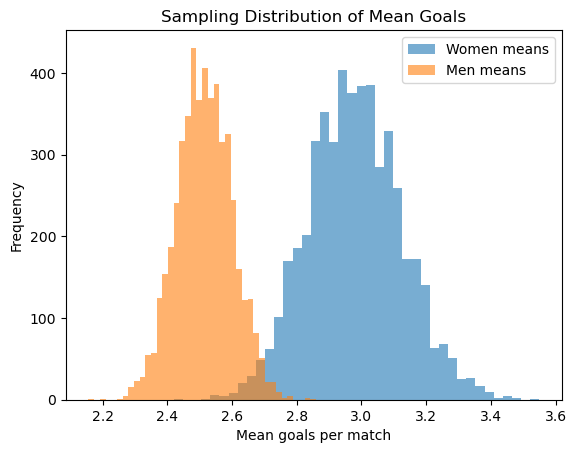

In [16]:
plt.hist(women_means, bins=40, alpha=0.6, label="Women means")
plt.hist(men_means, bins=40, alpha=0.6, label="Men means")
plt.legend()
plt.title("Sampling Distribution of Mean Goals")
plt.xlabel("Mean goals per match")
plt.ylabel("Frequency")
plt.show()

## Show numerically that mean distribution is normal

In [17]:
print(shapiro(women_means))
print(shapiro(men_means))

ShapiroResult(statistic=0.9988033890288903, pvalue=0.0010130938128627425)
ShapiroResult(statistic=0.9994300049960465, pvalue=0.12704898174909196)


## one-tailed test: women > men

In [23]:
stat, p_val = mannwhitneyu(
    women_goals,
    men_goals,
    alternative="greater"
)

alpha = 0.10

if p_val < alpha:
    decision = "reject"
else:
    decision = "fail to reject"

result_dict = {
    "p_val": p_val,
    "result": decision
}

result_dict

{'p_val': 0.005106609825443641, 'result': 'reject'}